# Generación de Texto con modelos GPT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion5/1-text-generation.ipynb)

En este notebook harémos uso de un modelo tipo GPT-2 pre-entrenado en idioma español que utilizaremos para generar texto a partir de un contexto inicial que proveerémos. Luego, harémos fine tuning a este modelo con un dataset de chistes en español y observar como cambia la generación de texto en función del dataset que utilicemos.

#### Referencias
- Dataset: https://huggingface.co/datasets/mrm8488/CHISTES_spanish_jokes
- [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [GPT2 Spanish](https://huggingface.co/DeepESP/gpt2-spanish)
- [Fine-Tune a non-Englush GPT-2 Model with Huggingface](https://www.philschmid.de/fine-tune-a-non-english-gpt-2-model-with-huggingface)

In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

C:\Users\rchic\AppData\Local\Temp\ipykernel_42992\2396000874.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Generative pre-training Transformer - GPT

![](https://github.com/Ohtar10/icesi-nlp/blob/main/assets/gpt.png?raw=1)

Los modelos tipo GPT, introducidos por Radfor, et.al., de OpenAI, al igual que los modelos BERT, hacen uso extensivo de la arquitectura de transformers como hemos estado viendo. Las diferencias claves se podrían resumir en:

1. GPT utiliza bloques de **Transformer Decoder** encadenados, mientras que el modelo BERT utiliza bloques de *Transformer Encoder*
2. GPT se centra en la generación de texto basado en un contexto, la tarea principal es la predicción del siguiente token en la secuencia, mientras que BERT se centra en el completado de partes de una secuencia, en función de un contexto anterior y posterior a la secuencia de entrada. Entonces BERT se centra en la construicción de representación de lenguage, mientras que GPT se centra en la generación de texto en función de un contexto.

Sin embargo, ambos se basan en la misma premisa de pre-entrenar el modelo en tareas no-supervisadas o semi-supervisadas para que el modelo aprenda las representaciones semánticas del lenguage y luego al modelo se le pueda hacer fine tuning a tareas posteriores.

In [2]:
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer


device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "Amloii/gpt2-reviewspanish"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

model.resize_token_embeddings(len(tokenizer))

model

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: Amloii/gpt2-reviewspanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [3]:
# Mostramos la cantidad de parametros del modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Cantidad total de parámetros del modelo: {total_params:,}")

Cantidad total de parámetros del modelo: 124,439,808


In [4]:
modules = [m for m, _ in model.named_modules()]
modules

['',
 'transformer',
 'transformer.wte',
 'transformer.wpe',
 'transformer.drop',
 'transformer.h',
 'transformer.h.0',
 'transformer.h.0.ln_1',
 'transformer.h.0.attn',
 'transformer.h.0.attn.c_attn',
 'transformer.h.0.attn.c_proj',
 'transformer.h.0.attn.attn_dropout',
 'transformer.h.0.attn.resid_dropout',
 'transformer.h.0.ln_2',
 'transformer.h.0.mlp',
 'transformer.h.0.mlp.c_fc',
 'transformer.h.0.mlp.c_proj',
 'transformer.h.0.mlp.act',
 'transformer.h.0.mlp.dropout',
 'transformer.h.1',
 'transformer.h.1.ln_1',
 'transformer.h.1.attn',
 'transformer.h.1.attn.c_attn',
 'transformer.h.1.attn.c_proj',
 'transformer.h.1.attn.attn_dropout',
 'transformer.h.1.attn.resid_dropout',
 'transformer.h.1.ln_2',
 'transformer.h.1.mlp',
 'transformer.h.1.mlp.c_fc',
 'transformer.h.1.mlp.c_proj',
 'transformer.h.1.mlp.act',
 'transformer.h.1.mlp.dropout',
 'transformer.h.2',
 'transformer.h.2.ln_1',
 'transformer.h.2.attn',
 'transformer.h.2.attn.c_attn',
 'transformer.h.2.attn.c_proj',
 'tran

Observermos un ejemplo de generación simple.

In [5]:
text = "Fue una curiosa"
best = 10

with torch.no_grad():
    tokens = tokenizer(text, return_tensors='pt')['input_ids'].to(device)
    print("Dimensiones de la entrada:", tokens.shape)
    output = model(input_ids=tokens)
    print("Dimensiones de la salida:", output.logits.shape)
    output = output.logits[0, -1, :]
    print("Dimensiones del último token de la secuencia:", output.shape)
    probs = torch.softmax(output, dim=-1)
    print("Dimensiones de la probabilidad de los tokens:", probs.shape)
    sorted_probs = torch.argsort(probs, dim=-1, descending=True)
    print({tokenizer.decode(token): f"{prob.cpu().numpy() * 100:.2f}%" for token, prob in zip(sorted_probs[:best], probs[sorted_probs[:best]])})

Dimensiones de la entrada: torch.Size([1, 3])
Dimensiones de la salida: torch.Size([1, 3, 50257])
Dimensiones del último token de la secuencia: torch.Size([50257])
Dimensiones de la probabilidad de los tokens: torch.Size([50257])
{' historia': '21.38%', ' compra': '8.32%', ' y': '6.31%', ' sorpresa': '3.87%', ' novela': '3.26%', ' experiencia': '2.33%', ' forma': '1.88%', ' manera': '1.53%', ' lectura': '1.08%', ' combinación': '1.05%'}


## Implementando una función de generación

Ahora, la idea es que este modelo nos sirva para generar texto de forma recurrente e incremental. En la última capa de los modelos tipo GPT encontrarémos un tensor con forma $(b, s, v)$, donde:

- $b$: Es el tamaño del bache, o la cantidad de secuencias a procesar.
- $s$: Es la longitud de la secuencia de entrada.
- $v$: Es el tamaño del vocabulario del modelo, cuantos tokens soporta.

Pero este es el tensor de salida, por qué tiene la forma de la secuencia de entrada?, porque cada posición en la salida corresponde a la la predicción del siguiente token de esa posición en la secuencia de entrada. En otras palabras, lo que obtenemos como predicción, es una secuencia de igual tamaño a la de entrada, movida un token hacia adelante, lo que efectivamente nos predice un solo token a la vez y por ende, el token que nos insteresa, es el último.

Lo que obtenemos en este tensor es además los logits de TODO el vocabulario del modelo, con los cuales podemos calcular las probabilidades de que cada uno sea el que continue en la secuencia. Hay varias formas de decodificar el siguiente token, la más fácil de implementar sería una decodificación codiciosa (greedy) del siguiente token, que consiste simplemente en seleccionar el token con la probabilidad más alta. Este es un enfoque simple y efectivo para algunos casos, pero al mismo tiempo sufre de poca variabilidad e incluso puede caer en generación repetitiva.

Otra opción es el muestreo, ya que justamente podemos obtener probabilidades del siguiente token, lo más lógico sería muestrear con esas opciones de probabilidad, de este modo podemos obtener mayor diversidad a la hora de generar el texto, al costo eso si de que haya mayor aleatoridad ya que se le daría la oportunidad a incluso tokens con baja probabilidad, de ser seleccionados.

Otra opción podría ser un balanceo entre una decodificación greedy y una por muestreo, en función de otro hiperparámetro que podemos definir. Esta sería una técnica muy común en el contexto de Reinforcement Learning llamade e-greedy. Se hace la aclaración de que en este ejemplo no harémos nada de RL, solamente se hace mención de esta técnica para balancear entre explotación y exploración.

In [6]:
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Optional, Tuple
from transformers.tokenization_utils_base import PreTrainedTokenizerBase


def generate(
        model: nn.Module,
        tokenizer: PreTrainedTokenizerBase,
        start: str,
        max_length: int = 100,
        eps: float = 0.5,
        top_n: int = 5,
        return_iterations: bool = False,
        device: str = "cpu") -> Tuple[str, Optional[pd.DataFrame]]:

    output = [start]
    iterations = []
    with torch.no_grad():
        input_ids = tokenizer(output[-1], return_tensors='pt')['input_ids'].to(device)
        for _ in range(max_length):
            # Tomamos los logits producidos por la última capa del modelo
            # Estos corresponden al siguiente token por cada posición de la cadena
            logits = model(input_ids=input_ids).logits
            # Por lo tanto, el que nos interesa es el último, que correspondería a la
            # predicción del siguiente token después del final de la cadena original
            # A este aplicamos un softmax para obtener las probabilidades por cada
            # token del vocabulario para estar presente en la cadena.
            probs = torch.softmax(logits[0, -1, :], dim=-1)
            # Simplemente ordenamos por probabilidad de forma descendente
            sorted_tokens = torch.argsort(probs, dim=-1, descending=True)

            # Utilizamos una politica tipo e-greedy para obtener el siguiente token de la secuencia
            # Un eps>=1 quiere decir que siempre se va seleccionar el token de forma 'greedy', es decir
            # siempre se toma el token con probabilidad más alta.

            # Un eps=0 quiere decir que siempre se va a muestrear el siguiente token en función
            # de las probabilidades de cada token

            # Un 0<eps<1 va a balancear de forma binomial entre tomar el token con la
            # probabilidad más alta y muestrear el token en función de sus probabilidades.
            if np.random.random_sample(1)[0] < eps:
                # Se toma el mejor token
                next_token = sorted_tokens[0].unsqueeze(dim=0)
            else:
                # Se muetrea el token de la probabilidad de distribución
                next_token = torch.multinomial(probs, 1)

            if return_iterations:
                # Mantenemos pista de todas las iteraciones para análisis
                iteration = {'input': ''.join(output)}
                best_n = sorted_tokens[:top_n].cpu().tolist()
                choices = {f'Choice #{choice+1}': f'{tokenizer.decode(token)} ({prob:.4f})' for choice, (token, prob) in enumerate(zip(best_n, probs[best_n].cpu().tolist()))}
                iteration.update(choices)
                iterations.append(iteration)

            output.append(tokenizer.decode(next_token))
            input_ids = torch.cat([input_ids, next_token.unsqueeze(dim=0)], dim=-1)

        output_text = ''.join(output)
        if not return_iterations:
            return output_text, None
        else:
            df = pd.DataFrame(iterations)
            return output_text, df

Ahora observemos que pasa cuando generamos texto con nuestra función y algunos parámetros.

Primero, observemos que pasa cuando pasamos un `eps=1` que quiere decir que la generación va a ser de tipo greedy:

In [7]:
output_text, iterations_df = generate(model, tokenizer, text, max_length=15, eps=1.0, top_n=10, return_iterations=True, device=device)
print(output_text)
iterations_df.head(15)

Fue una curiosa historia de amor entre dos personas que se enamoran y se enamoran.


,input,Choice #1,Choice #2,Choice #3,Choice #4,Choice #5,Choice #6,Choice #7,Choice #8,Choice #9,Choice #10
0,Fue una curiosa,historia (0.2138),compra (0.0832),y (0.0631),sorpresa (0.0387),novela (0.0326),experiencia (0.0233),forma (0.0188),manera (0.0153),lectura (0.0108),combinación (0.0105)
1,Fue una curiosa historia,de (0.1791),que (0.1606),", (0.1470)",. (0.1085),para (0.0432),y (0.0363),con (0.0315),en (0.0229),sobre (0.0183),muy (0.0110)
2,Fue una curiosa historia de,amor (0.3699),un (0.0607),una (0.0417),la (0.0345),cómo (0.0205),los (0.0150),suspen (0.0134),lo (0.0110),viajes (0.0089),dos (0.0086)
3,Fue una curiosa historia de amor,entre (0.1678),", (0.1467)",y (0.1247),que (0.1065),. (0.1030),de (0.0484),con (0.0455),en (0.0319),para (0.0161),... (0.0125)
4,Fue una curiosa historia de amor entre,dos (0.3068),una (0.0667),los (0.0460),un (0.0440),ambos (0.0341),ellos (0.0295),mujeres (0.0200),el (0.0193),las (0.0185),padres (0.0168)
5,Fue una curiosa historia de amor entre dos,personas (0.6086),mujeres (0.0986),hombres (0.0316),amantes (0.0280),protagonistas (0.0189),niños (0.0172),adolescentes (0.0170),jóvenes (0.0168),personajes (0.0168),amigos (0.0147)
6,Fue una curiosa historia de amor entre dos per...,que (0.2888),. (0.1740),", (0.1606)",y (0.0821),a (0.0519),: (0.0223),adul (0.0222),en (0.0110),... (0.0096),unidas (0.0096)
7,Fue una curiosa historia de amor entre dos per...,se (0.1576),no (0.0556),han (0.0456),te (0.0338),quieren (0.0260),am (0.0243),enamor (0.0236),me (0.0235),ha (0.0173),le (0.0172)
8,Fue una curiosa historia de amor entre dos per...,enamor (0.4577),quieren (0.0692),han (0.0632),am (0.0323),encuentran (0.0225),sienten (0.0207),aman (0.0206),hacen (0.0176),querían (0.0142),ha (0.0125)
9,Fue una curiosa historia de amor entre dos per...,an (0.8495),aron (0.1271),aban (0.0211),arán (0.0004),aran (0.0003),as (0.0002),arían (0.0002),aba (0.0002),ó (0.0001),en (0.0001)


Observamos como el input progresa a la vez que las opciones de tokens que hay. Sin importar cuantas veces invoquemos a la función con los mismos parámetros, siempre vamos a obtener los mismos resultados.

Ahora, observemos que pasa si introducimos exploración al reducir el `eps=0.5`, lo cual nos dice que aproximadamente la mitad de las veces va a elegir el siguiente token muestreando y la otra mitad explotando.

In [8]:
output_text, _ = generate(model, tokenizer, text, max_length=100, eps=0.5, device=device)
print(output_text)

Fue una curiosa historia contada por los protagonistas.  Flexiono y muy original. Ofrece un acceso de video a los vídeos de YouTube y samsung.  Magnífico producto, muy satisfecho con el, el producto es tal y como se describe. Servicio de entrega muy rápido.  Muy contenta con la compra. Es eficaz y rápido. Cumple con las expectativas. Super suave y suave. Volvería a comprarlo.  Producto genial, muy practico y barata  Muy prácticos y sobre


En este caso, cada vez que invoquemos a la función, vamos a obtener una respuesta diferente, a veces más coherente y otras veces menos. Vale la pena realizar varias pruebas para observar los resultados hasta encontrar un balance.

### Generando texto con las utilidades del modelo

Ahora, la clase de Huggingface implementa la función `generate` que hace la labor de generación por nosotros, incluyendo las opciones de muestreo y explotación como hemos observado. Solo que además permite otra serie de parámetros y opciones para controlar la generación de texto. Para más información se recomienda estudiar:

- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246), Capitulo 5
- https://huggingface.co/docs/transformers/v4.41.3/en/main_classes/text_generation#transformers.GenerationConfig
- https://huggingface.co/docs/transformers/v4.41.3/en/main_classes/text_generation#transformers.GenerationMixin.generate

In [9]:
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=100, do_sample=True, temperature=0.5, top_k=0)
print(tokenizer.decode(output[0]))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Fue una curiosa historia de amor que me ha enganchado desde el principio. Me ha parecido una historia que me ha dado una vida nueva.  Me gusta mucho el diseño y la forma de sujetarlo. La verdad es que me ha gustado mucho el diseño de la correa. Es muy cómoda y no se mueve nada. Cumple con su función.  Se adapta perfectamente, es un buen teléfono y cumple su función perfectamente.  Perfecto para el día a día.  Muy buen producto, es muy


## Fine tuning

Ahora, intentemos hacer fine tuning a nuestro modelo. Intentemos entrenarlo en un corpus de chistes en idioma español y ver como la narrativa de su output cambia.

##### Nota
Lastimosamente, este dataset es muy pequeño y la distribución del texto es muy diferente a la distribución de texto con la cual fue entrenado el modelo original, por lo que no se esperan resultados significativamente ejemplares. Sin embargo, el objetivo es observar como cambia la generación del texto una vez lo entrenamos en un conjunto especializado.

In [10]:
import pandas as pd
from datasets import Dataset, DatasetDict

# Cargamos el archivo CSV
csv_path = "Balanced_AHR.csv"
df = pd.read_csv(csv_path)

# Columna de texto: el CSV tiene "review_text"; la renombramos a "text"
# para que sea compatible con el resto del notebook (igual que el dataset de chistes).
text_col = "review_text" if "review_text" in df.columns else df.columns[3]
df_text = df[[text_col]].rename(columns={text_col: "text"}).dropna()

# Dataset.from_pandas devuelve un Dataset plano (sin splits).
# El resto del notebook espera un DatasetDict con clave 'train',
# igual que load_dataset("mrm8488/CHISTES_spanish_jokes").
# Por eso envolvemos el Dataset en un DatasetDict.
dataset = DatasetDict({
    "train": Dataset.from_pandas(df_text, preserve_index=False)
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 7615
    })
})

In [11]:
dataset['train'][0]

{'text': 'El fin de semana mi pareja y yo hicimos una reserva en este hotel, con el fin de descansar y desconectar, fue sólo una noche y menos mal.  Nos llevaron a un ala bastante apartada del hotel porque nos dijeron que era mejor para descansar ya que la parte de fuera era muy “jaleosa”. Nos pareció bien porque era justo lo que buscábamos, y cuál fue nuestra sorpresa? Desde las 6 de la mañana con ruidos, primero lo que suponemos que eran unos tacones en la habitación de arriba (de eso no tiene culpa el hotel, obviamente) y después sobre las 7 o poco más, las limpiadoras moviendo muebles y arrastrando sofás o lo que fuera. Habíamos cogido sólo alojamiento para descansar, pensando en no tener que madrugar como habitualmente, pero fue IMPOSIBLE por los ruidos constantes.  Por destacar algo…'}

In [12]:
dataset.set_format('pandas')
df = dataset['train'].to_pandas()
df.head(10)

,text
0,El fin de semana mi pareja y yo hicimos una re...
1,"El hotel en general está bien, las habtiacione..."
2,"El hotel es moderno, amplio y limpio, pero no ..."
3,Calefacción averiada o no operativa. Se coment...
4,Este hotel ha bajado notoriamente su categoria...
5,"Son pequeños, se bloquean y son insuficientes ..."
6,Mal mal y mal. Una enorme diferencia de trato ...
7,Jamás me he encontrado un nivel de suciedad co...
8,Lamentable elegir un hotel de cuatro estrellas...
9,El hotel fantástico. Los desayunos muy buenos...


In [13]:
df['Palabras por chiste'] = df['text'].str.split().apply(len)
df['Palabras por chiste'].median()

np.float64(68.0)

Aquí podemos observar que la mediana de longitud en terminos de palabras es de 31. Esto es esperado, pues los chistes deben ser cortos por naturaleza. Por otra parte, es bastante claro que el corpus original del modelo pre-entrenado contenía texto muy diferente a este, por lo que la calidad de los resultados, sin hacer mayores modificaciones puede que no sea buena.

Sin embargo, a manera demostrativa, continuarémos con el ejercicio, prepararémos el conjunto de datos para entrenamiento.

In [14]:
def preprocess_function(max_len):
    def _preprocess_function(examples):
        return tokenizer(examples['text'], max_length=max_len, truncation=True)
    return _preprocess_function


Los modelos GPT no esperan otra cosa más que los `input_ids`, por lo que retirarémos todas las demás columnas del dataset ya que no nos son de utilidad en este momento.

In [15]:
dataset.reset_format()
tokenized_dataset = dataset['train'].map(preprocess_function(max_len=64), batched=True)
tokenized_dataset = tokenized_dataset.remove_columns([col for col in tokenized_dataset.column_names if col not in ['input_ids', 'attention_mask']])
tokenized_dataset = tokenized_dataset.train_test_split(train_size=0.9)
tokenized_dataset.set_format('torch')
tokenized_dataset

Map:   0%|          | 0/7615 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 6853
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 762
    })
})

Finalmente procedemos a definir el entrenamiento. Observaremos que es muy similar a como entrenamos a BERT.

In [16]:
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments


batch_size = 32
logging_steps = len(tokenized_dataset['train']) // batch_size
# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./hf-gpt',
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='none'
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
)

In [17]:
%%time
trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.815879,3.554104
2,3.470996,3.437630
3,3.325120,3.386926
4,3.260136,3.371095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


CPU times: total: 4min 17s
Wall time: 4min 22s


TrainOutput(global_step=860, training_loss=3.466850925046344, metrics={'train_runtime': 262.2805, 'train_samples_per_second': 104.514, 'train_steps_per_second': 3.279, 'total_flos': 895317147648000.0, 'train_loss': 3.466850925046344, 'epoch': 4.0})

Ahora observemos los resultados.

In [18]:
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=50, do_sample=True, temperature=0.8)
print(tokenizer.decode(output[0]))

Fue una curiosa experiencia en el ático. El apartamento es bastante pequeño pero lo suficiente para dormir. Es muy amplio y cómodo de llevar.  La habitación era grande y disponía de todo lo necesario para una estancia tranquila. El desayuno muy bueno y la comida


In [19]:
output_text, _ = generate(model, tokenizer, text, max_length=50, eps=0.5, device=device)
print(output_text)

Fue una curiosa experiencia con estas instalaciones. La habitación Incluía una gran cama de matrimonio, con una cama de matrimonio y una cama de matrimonio. También , la cocina, con sus utensilios y sus utensilios, y la habitación, triplemente tenue. En resumen,


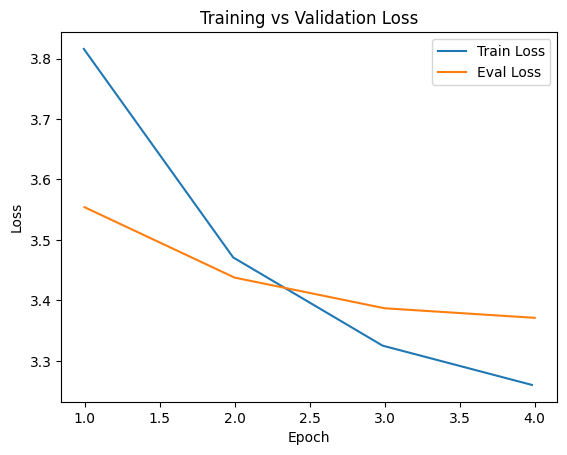

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_logs = df[df['loss'].notna()]
eval_logs = df[df['eval_loss'].notna()]

plt.plot(train_logs['epoch'], train_logs['loss'], label='Train Loss')
plt.plot(eval_logs['epoch'], eval_logs['eval_loss'], label='Eval Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

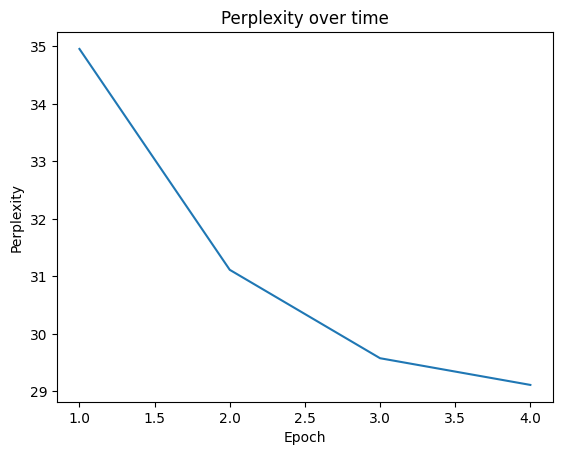

In [21]:
eval_logs['perplexity'] = np.exp(eval_logs['eval_loss'])

plt.plot(eval_logs['epoch'], eval_logs['perplexity'])
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity over time")
plt.show()

In [23]:
def distinct_n(texts, n=1):
    import collections
    ngrams = []
    for t in texts:
        tokens = t.split()
        ngrams += list(zip(*[tokens[i:] for i in range(n)]))
    return len(set(ngrams)) / max(len(ngrams), 1)

generations = [output_text] 
print("Distinct-1:", distinct_n(generations, 1))
print("Distinct-2:", distinct_n(generations, 2))

Distinct-1: 0.6904761904761905
Distinct-2: 0.926829268292683


In [26]:
import collections
def count_and_display_repeated_words(text):
    words = text.lower().split()
    word_counts = collections.Counter(words)
    repeated_words = {word: count for word, count in word_counts.items() if count > 1}
    
    if repeated_words:
        print("Conteo de palabras iguales dentro del resultado generado:")
        for word, count in repeated_words.items():
            print(f"- '{word}': {count} times")
    else:
        print("No hay palabras repetidas en output_text.")

    return word_counts

word_counts_output_text = count_and_display_repeated_words(output_text)

Conteo de palabras iguales dentro del resultado generado:
- 'una': 4 times
- 'con': 3 times
- 'la': 3 times
- 'cama': 3 times
- 'de': 3 times
- 'y': 3 times
- 'sus': 2 times


No parece ser muy gracioso precisamente, sin embargo, notemos que la generación de texto cambia de "estilo", ahora es mucho más frecuente encontrar conversaciones cortas, frases concisas, y situaciones particulares, en lugar del estilo más literario del modelo original. Esto es un indicio de la influencia que tiene el conjunto de datos de entrenamiento en el modelo final, esto es algo a tener muy en cuenta a la hora de utilizar y hacer fine tuning a modelos de lenguaje.

## Conclusiones
- Los modelos BERT y GPT son muy similares, aunque ambos tienen diferencias claras en cuanto a su estructura y manera de entrenamiento.
- Sin embargo, ambos pueden utilizarse para el mismo tipo de tareas posteriores, lo cual sustenta la importancia del pre-entrenamiento y la construcción de embeddings de buena calidad.
- En los modelos generativos, tiende a ver un dilema de tipo exploración-explitación, al explotar los resultados, podemos ser más precisos, per al mismo tiempo más monótonos, mientras que explorando podemos ser más creativos y diversos, pero al mismo tiempo terminar con texto incoherente, difuso o alucinante. Es necesario evaluar la tarea a la mano para escoger el ajuste adecuado entre estas dos técnicas de decodificación.
- Los modelos generativos de texto no son más que una gran probabilidad de distribución y esta a su vez es completamente dependiente de los datos con los que fue entrenada. Es aquí donde se hace sumamente importante obtener y curar los conjuntos de datos con los que se entrena, de lo contrario se puede terminar con un modelo de mala calidad para la tarea en especifico.
- Diferentes estrategias de decodificación entregan resultados diferentes, vale la pena hacer una exploración de los resultados y ajustar los hiperparámetros para obtener los resultados deseados según el objetivo.